# Etapa 6 — Backtest e Avaliação

Simulação histórica da lógica de decisão (RSI + MACD + sentimento neutro fixo), sem chamadas de LLM, para os 4 tickers monitorados.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

from quantumfinance.backtesting.metrics import calculate_metrics
from quantumfinance.backtesting.strategy import run_backtest
from quantumfinance.features.targets import IBOVESPA_TICKER
from quantumfinance.universe import TICKERS

C:\Users\ASUS\Desktop\MBA\ENTREGAS\ENTREGA_MULTI-AGENTS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
BACKTEST_OUTPUT_PATH = Path("data/backtest_results.csv")

if BACKTEST_OUTPUT_PATH.exists():
    existing = pd.read_csv(BACKTEST_OUTPUT_PATH)
    print(f"AVISO: {BACKTEST_OUTPUT_PATH} já existe com {len(existing)} linha(s).")
    if not existing.empty:
        print(f"Período coberto: {existing['date'].min()} a {existing['date'].max()}")
    print("Rodar a próxima célula (run_backtest) vai SOBRESCREVER esse arquivo.")
    print("Se quiser preservar o resultado atual, copie o arquivo antes de continuar.")
else:
    print(f"{BACKTEST_OUTPUT_PATH} ainda não existe — a próxima célula vai criá-lo.")

AVISO: data\backtest_results.csv já existe com 248 linha(s).
Período coberto: 2026-03-27 a 2026-06-26
Rodar a próxima célula (run_backtest) vai SOBRESCREVER esse arquivo.
Se quiser preservar o resultado atual, copie o arquivo antes de continuar.


In [3]:
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")
start_date = (pd.Timestamp.today() - pd.DateOffset(months=3)).strftime("%Y-%m-%d")

results = run_backtest(TICKERS, start_date, end_date, output_path=str(BACKTEST_OUTPUT_PATH), use_gdelt=False)
print(f"Período: {start_date} a {end_date}")
print(f"Total de linhas: {len(results)}")
results.head()

$PETR4.SA: possibly delisted; no price data found  (1d 2026-04-03 -> 2026-04-04)



1 Failed download:


['PETR4.SA']: possibly delisted; no price data found  (1d 2026-04-03 -> 2026-04-04)


$VALE3.SA: possibly delisted; no price data found  (1d 2026-04-03 -> 2026-04-04)



1 Failed download:


...

$ITUB4.SA: possibly delisted; no price data found  (1d 2026-06-04 -> 2026-06-05)



1 Failed download:


['ITUB4.SA']: possibly delisted; no price data found  (1d 2026-06-04 -> 2026-06-05)


Período: 2026-03-27 a 2026-06-27
Total de linhas: 248


,date,ticker,recommendation,confidence,rsi,macd_signal,sentiment_score,sentiment_source,forward_return_5d,ibovespa_return_5d,beat_ibov
0,2026-03-27,PETR4,VENDER,0.67,79.21,bullish,0.5,placeholder,-0.9512,3.6380,False
1,2026-03-27,VALE3,AGUARDAR,0.50,44.45,bearish,0.5,placeholder,5.1772,3.6380,True
2,2026-03-27,BBAS3,AGUARDAR,0.50,38.05,bearish,0.5,placeholder,3.3981,3.6380,False
3,2026-03-27,ITUB4,AGUARDAR,0.50,41.75,bearish,0.5,placeholder,4.9655,3.6380,True
4,2026-03-30,PETR4,VENDER,0.67,82.09,bullish,0.5,placeholder,-2.3354,3.1477,False


In [4]:
metrics = calculate_metrics(results)
for key, value in metrics.items():
    print(f"{key}: {value}")

accuracy: 0.443
beat_ibov_rate: 0.5307
avg_return_on_buy: -0.3258
avg_return_on_sell: -1.0515
recommendation_counts: {'AGUARDAR': 113, 'COMPRAR': 84, 'VENDER': 51}
sharpe_proxy: -0.199


## Gráfico 1 — Retorno acumulado: agente vs. buy-and-hold vs. Ibovespa

Para cada ticker, a posição do "agente" no dia é definida pela recomendação daquele dia
(COMPRAR = +1, VENDER = -1, AGUARDAR = 0), aplicada ao retorno diário real do ativo.

In [5]:
from pathlib import Path
Path("reports/figures").mkdir(parents=True, exist_ok=True)

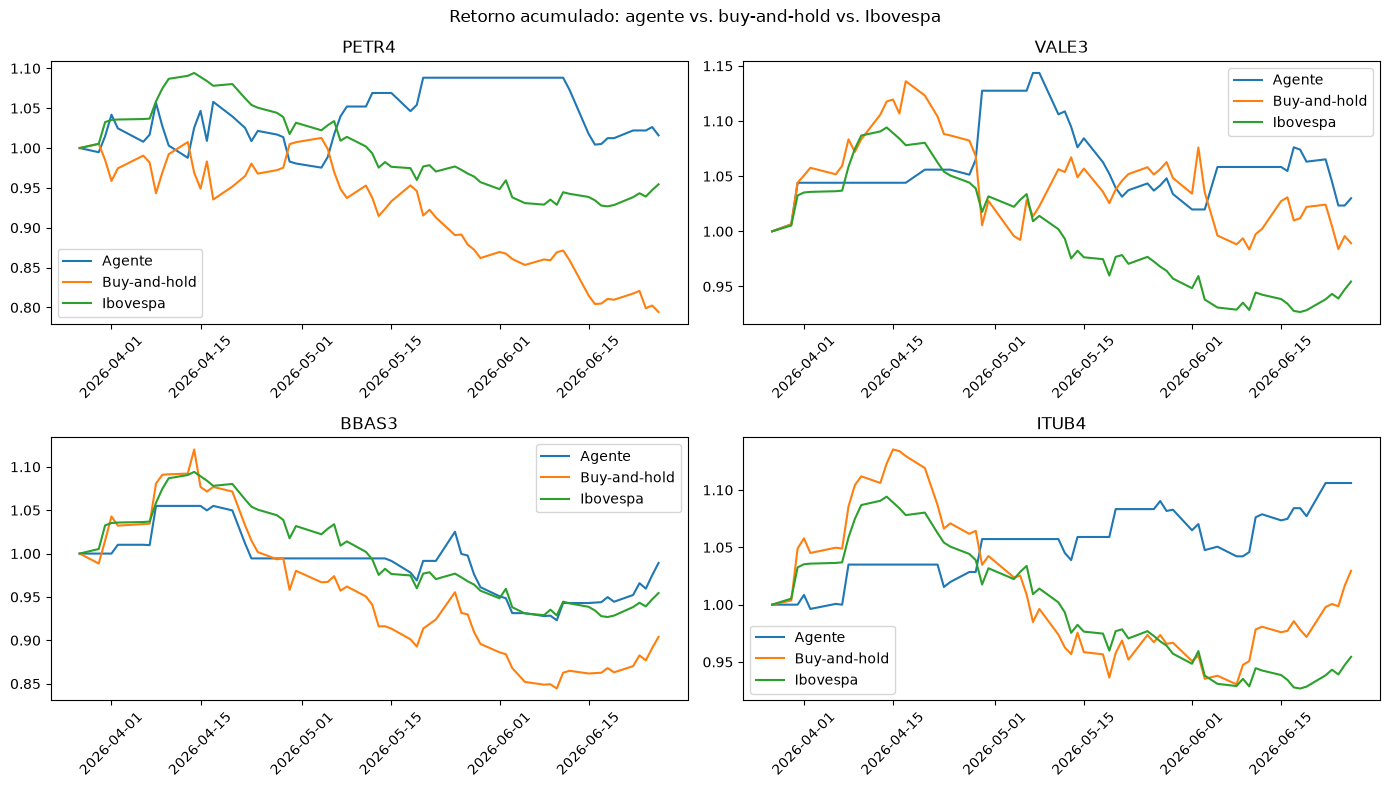

In [6]:
def build_equity_curves(ticker: str, results: pd.DataFrame, start_date: str, end_date: str):
    """Constrói as séries de retorno acumulado: agente vs. buy-and-hold vs. Ibovespa."""
    position_map = {"COMPRAR": 1, "VENDER": -1, "AGUARDAR": 0}

    yf_ticker = f"{ticker}.SA"
    prices = yf.download(yf_ticker, start=start_date, end=end_date, progress=False, auto_adjust=True)
    if isinstance(prices.columns, pd.MultiIndex):
        prices.columns = prices.columns.get_level_values(0)
    daily_returns = prices["Close"].pct_change().fillna(0)

    ticker_results = results[results["ticker"] == ticker].set_index("date")

    positions = pd.Series(0.0, index=daily_returns.index)
    for d in daily_returns.index:
        date_str = d.strftime("%Y-%m-%d")
        if date_str in ticker_results.index:
            positions.loc[d] = position_map.get(ticker_results.loc[date_str, "recommendation"], 0)

    agent_curve = (1 + positions * daily_returns).cumprod()
    buy_hold_curve = (1 + daily_returns).cumprod()

    ibov_prices = yf.download(IBOVESPA_TICKER, start=start_date, end=end_date, progress=False, auto_adjust=True)
    if isinstance(ibov_prices.columns, pd.MultiIndex):
        ibov_prices.columns = ibov_prices.columns.get_level_values(0)
    ibov_returns = ibov_prices["Close"].pct_change().fillna(0)
    ibov_curve = (1 + ibov_returns).cumprod()

    return agent_curve, buy_hold_curve, ibov_curve


fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, ticker in zip(axes.flat, TICKERS):
    agent_curve, buy_hold_curve, ibov_curve = build_equity_curves(ticker, results, start_date, end_date)
    ax.plot(agent_curve.index, agent_curve.values, label="Agente")
    ax.plot(buy_hold_curve.index, buy_hold_curve.values, label="Buy-and-hold")
    ax.plot(ibov_curve.index, ibov_curve.values, label="Ibovespa")
    ax.set_title(ticker)
    ax.legend()
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Retorno acumulado: agente vs. buy-and-hold vs. Ibovespa")
plt.tight_layout()
plt.savefig("reports/figures/retorno_acumulado.png")
plt.show()

## Gráfico 2 — Distribuição das recomendações por ticker

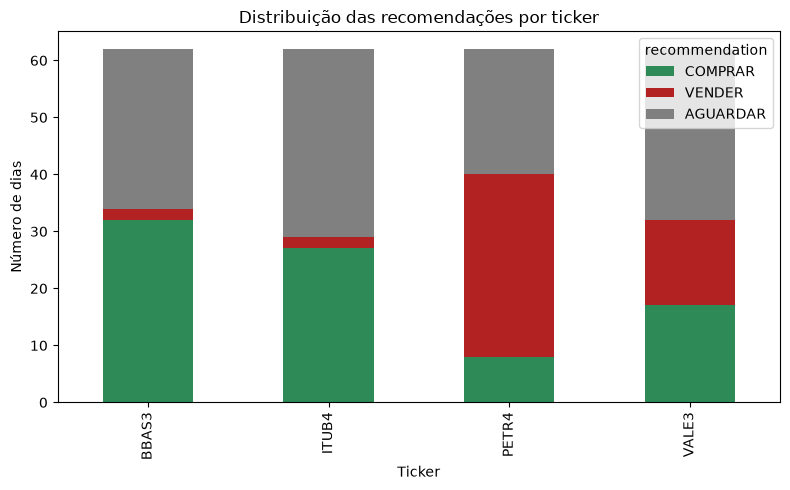

In [7]:
counts = results.groupby(["ticker", "recommendation"]).size().unstack(fill_value=0)
for col in ["COMPRAR", "VENDER", "AGUARDAR"]:
    if col not in counts.columns:
        counts[col] = 0
counts = counts[["COMPRAR", "VENDER", "AGUARDAR"]]

ax = counts.plot(kind="bar", stacked=True, figsize=(8, 5), color=["seagreen", "firebrick", "gray"])
ax.set_title("Distribuição das recomendações por ticker")
ax.set_xlabel("Ticker")
ax.set_ylabel("Número de dias")
plt.tight_layout()
plt.savefig("reports/figures/distribuicao_recomendacoes.png")
plt.show()

## Gráfico 3 — RSI médio por tipo de recomendação

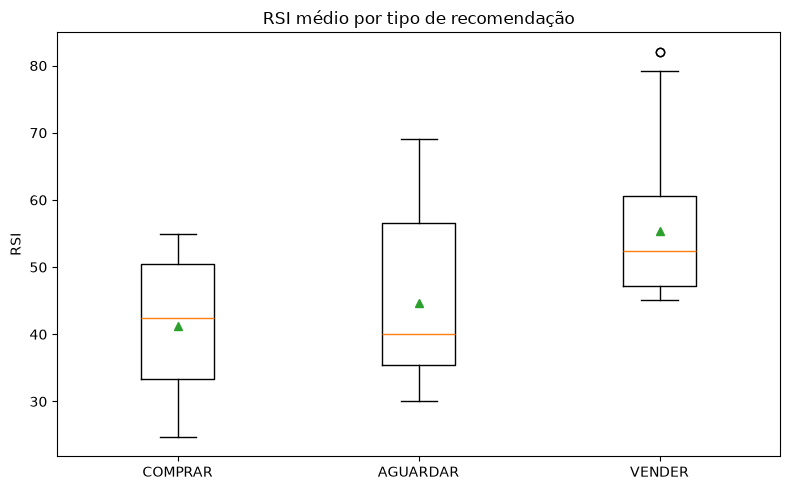

In [8]:
order = ["COMPRAR", "AGUARDAR", "VENDER"]
data_by_rec = [results.loc[results["recommendation"] == rec, "rsi"] for rec in order]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(data_by_rec, tick_labels=order, showmeans=True)
ax.set_title("RSI médio por tipo de recomendação")
ax.set_ylabel("RSI")
plt.tight_layout()
plt.savefig("reports/figures/rsi_por_recomendacao.png")
plt.show()

## Limitação do sentimento histórico (Etapa 6 — superada na Etapa 6.5 abaixo)

O sentimento de notícias não está disponível para datas passadas via RSS.
O backtest acima (`use_gdelt=False`) usa sentiment_score=0.5 (neutro) para todas as datas históricas,
o que significa que os resultados refletem principalmente a qualidade dos
indicadores técnicos como sinais de decisão.

Esse era o comportamento padrão até a Etapa 6.5: a partir dela, sentimento histórico real
via GDELT/BigQuery passou a ser o padrão (`use_gdelt=True`). A comparação entre os dois
modos está nas células abaixo.

## Etapa 6.5 — Comparação: sentimento placeholder vs. GDELT/BigQuery

Carrega os dois CSVs gerados pelo backtest — `data/backtest_results.csv` (sentimento
placeholder neutro, célula acima, `use_gdelt=False`) e `data/backtest_results_gdelt.csv`
(sentimento histórico real via GDELT/BigQuery, `use_gdelt=True`, gerado por
`scripts/run_backtest_gdelt.py`) — e compara as métricas dos dois modos lado a lado.

In [9]:
GDELT_OUTPUT_PATH = Path("data/backtest_results_gdelt.csv")

results_placeholder = pd.read_csv(BACKTEST_OUTPUT_PATH)
results_gdelt = pd.read_csv(GDELT_OUTPUT_PATH)

metrics_placeholder = calculate_metrics(results_placeholder)
metrics_gdelt = calculate_metrics(results_gdelt)

comparison = pd.DataFrame(
    {"placeholder (neutro)": metrics_placeholder, "gdelt (BigQuery)": metrics_gdelt}
)
comparison

,placeholder (neutro),gdelt (BigQuery)
accuracy,0.443,0.4241
beat_ibov_rate,0.5307,0.5312
avg_return_on_buy,-0.3258,-0.5882
avg_return_on_sell,-1.0515,-0.7514
recommendation_counts,"{'AGUARDAR': 113, 'COMPRAR': 84, 'VENDER': 51}","{'AGUARDAR': 109, 'COMPRAR': 82, 'VENDER': 53}"
sharpe_proxy,-0.199,-0.2006


### Dias em que o sentimento GDELT divergiu do neutro

`apply_decision_rules` só deixa o sentimento influenciar a recomendação quando
`sentiment_score > 0.6` (altista) ou `< 0.4` (baixista) — entre esses limiares o
efeito é o mesmo do placeholder neutro. O gráfico abaixo destaca os dias/tickers
em que a recomendação do modo GDELT difere da do modo placeholder.

Dias/tickers com dados nos dois modos: 240
Dias em que a recomendação mudou por causa do sentimento real: 2


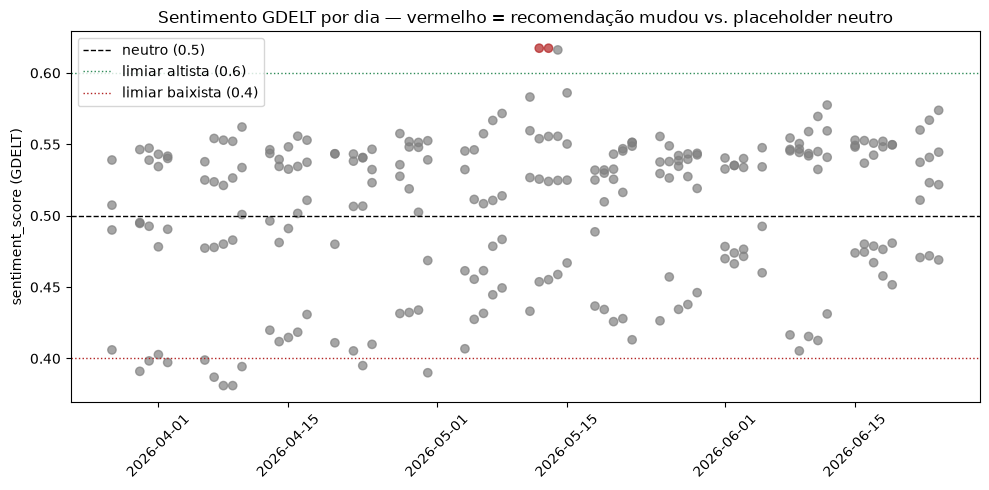

,date,ticker,sentiment_score_gdelt,recommendation_placeholder,recommendation_gdelt
118,2026-05-12,BBAS3,0.6173,AGUARDAR,COMPRAR
122,2026-05-13,BBAS3,0.6173,AGUARDAR,COMPRAR


In [10]:
merged = results_placeholder.merge(
    results_gdelt,
    on=["date", "ticker"],
    suffixes=("_placeholder", "_gdelt"),
    how="inner",
)
diverged = merged[merged["recommendation_placeholder"] != merged["recommendation_gdelt"]]

print(f"Dias/tickers com dados nos dois modos: {len(merged)}")
print(f"Dias em que a recomendação mudou por causa do sentimento real: {len(diverged)}")

merged_sorted = merged.sort_values("date")
colors = merged_sorted["recommendation_placeholder"].ne(merged_sorted["recommendation_gdelt"]).map(
    {True: "firebrick", False: "gray"}
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(pd.to_datetime(merged_sorted["date"]), merged_sorted["sentiment_score_gdelt"], c=colors, alpha=0.7)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="neutro (0.5)")
ax.axhline(0.6, color="seagreen", linestyle=":", linewidth=1, label="limiar altista (0.6)")
ax.axhline(0.4, color="firebrick", linestyle=":", linewidth=1, label="limiar baixista (0.4)")
ax.set_title("Sentimento GDELT por dia — vermelho = recomendação mudou vs. placeholder neutro")
ax.set_ylabel("sentiment_score (GDELT)")
ax.legend()
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("reports/figures/divergencia_sentimento_gdelt.png")
plt.show()

diverged[["date", "ticker", "sentiment_score_gdelt", "recommendation_placeholder", "recommendation_gdelt"]]

### Limitações do sentimento histórico via GDELT

- O GDELT cobre oficialmente apenas os últimos ~3 meses de artigos (limitação documentada
  da própria API/dataset, não um bug do cliente). O backtest de 90 dias está dentro dessa
  janela; datas mais antigas tendem a ter cobertura reduzida ou nula.
- Quando não há artigos no período `[date - window_days, date]` para o ticker (sem cobertura,
  ou data fora da janela oficial), `fetch_gdelt_sentiment` cai automaticamente no mesmo
  fallback neutro (`sentiment_score=0.5`) usado no modo placeholder — não há como distinguir
  "sem cobertura" de "sentimento genuinamente neutro" só pelo CSV.
- O `tone` do GDELT é um score geral de mídia (positivo/negativo do texto do artigo como um
  todo), não um score de sentimento financeiro especializado como o FinBERT-PT-BR usado no
  caminho principal do agente — é uma proxy razoável para o backtest histórico, mas não
  equivalente ao sentimento usado em produção.